# CLASSIFICATIE

In [2]:
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split




## TRAIN TEST SET

In [3]:
df_all = pd.read_csv('goedeoutput.csv')
df_all = df_all.drop_duplicates(subset='file')
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.575868,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.916088,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.862473,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.736694,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434


In [4]:
colomn_names = df_all.columns
colomn_names

# colomnen verwijderen
feature_names=['time', 'x', 'y', 'z', 'abs', 'weight', 'weather',
       'x_std', 'z_std', 'x_mean',
       'x_rms', 'z_rms',
       'z_spectral_flatness']
Y = df_all['roadtype']
X = df_all[feature_names]
X = pd.get_dummies(X, columns=['weather'], drop_first=True, dtype=int)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X.head()

,time,x,y,z,abs,weight,x_std,z_std,x_mean,x_rms,z_rms,z_spectral_flatness,weather_Dry,weather_Wet
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,0.0,0.373276,0.140477,0.067120,0.377403,0.139825,0.653138,1,0
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,0.0,2.181070,0.575868,-0.722286,2.287180,0.579284,0.574400,1,0
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,0.0,2.370932,0.916088,0.911198,2.528798,0.927195,0.745212,1,0
298,3.000444,3.016697,0.947292,-0.673180,3.232800,0.0,3.425790,0.862473,-0.349491,3.426488,0.860367,0.702190,1,0
398,4.005364,-0.492856,1.994679,0.532708,2.122600,0.0,2.177802,0.736694,0.466448,2.216413,0.740745,0.828434,1,0


## model

In [79]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)
classifier = RandomForestClassifier(n_estimators=100, random_state=12)
classifier.fit(x_train_scale, y_train)
y_pred = classifier.predict(x_test_scale)
ac = accuracy_score(y_test,y_pred)

print(f'de accuracy is {ac}')

de accuracy is 0.7252252252252253


In [80]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

correct_counts = results[results['Actual'] == results['Predicted']] \
                    .groupby('Actual') \
                    .size()

print(correct_counts)

percentages = correct_counts / results['Actual'].value_counts() * 100
print(percentages)

Actual
asphalt    40
bricks     33
grass      53
gravel     13
sand       13
wood        9
dtype: int64
Actual
asphalt     67.796610
bricks      61.111111
grass       92.982456
gravel      59.090909
sand       100.000000
wood        52.941176
dtype: float64


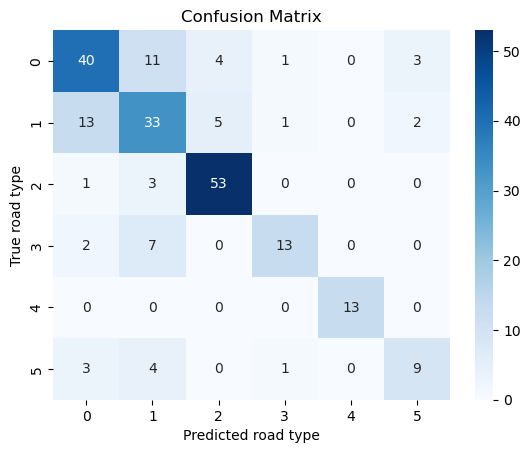

In [81]:
conf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted road type")
plt.ylabel("True road type")
plt.title("Confusion Matrix")
plt.show()

## met gridsearch

LET OP! gridsearch duurt 100 minuten

In [82]:
pipeline = make_pipeline(StandardScaler(), RandomForestClassifier()) #max_iter=1000, tol=1e-3))

param_grid = {
    'randomforestclassifier__n_estimators': [300, 500, 800],
    'randomforestclassifier__max_depth': [10, 20, 40, None],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__criterion': ['gini', 'entropy']
}




grid_cv = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=1, 
                       cv=7, 
                       verbose=2) 

grid_cv.fit(x_train, y_train)

Fitting 7 folds for each of 432 candidates, totalling 3024 fits
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.6s
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.6s
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.5s
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomfor

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=1,
             param_grid={'randomforestclassifier__criterion': ['gini',
                                                               'entropy'],
                         'randomforestclassifier__max_depth': [10, 20, 40,
                                                               None],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [300, 500,
                                                                  800]},
             verbose=2)

In [89]:
print(f'For the training set, using K-fold CV the best estimator is: {grid_cv.best_estimator_}')
print(f'Leading to an accuracy of: {grid_cv.best_score_}')
y_pred = grid_cv.best_estimator_.predict(x_test)
ass = accuracy_score(y_test,y_pred)
print(f'de accuracy score is {ass}')

For the training set, using K-fold CV the best estimator is: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(criterion='entropy', max_depth=40,
                                        n_estimators=300))])
Leading to an accuracy of: 0.7141696573642581
de accuracy score is 0.7342342342342343


In [84]:
param_grid = {
    'randomforestclassifier__n_estimators': [300, 500],
    'randomforestclassifier__max_depth': [20, None],
    'randomforestclassifier__min_samples_split': [2, 5],
    'randomforestclassifier__min_samples_leaf': [1, 2],
    'randomforestclassifier__max_features': ['sqrt']
}

grid_cv_simpel = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=1, 
                       cv=7, 
                       verbose=2) 

grid_cv_simpel.fit(x_train, y_train)

Fitting 7 folds for each of 16 candidates, totalling 112 fits
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.6s
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.6s
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.8s
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=30

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=1,
             param_grid={'randomforestclassifier__max_depth': [20, None],
                         'randomforestclassifier__max_features': ['sqrt'],
                         'randomforestclassifier__min_samples_leaf': [1, 2],
                         'randomforestclassifier__min_samples_split': [2, 5],
                         'randomforestclassifier__n_estimators': [300, 500]},
             verbose=2)

In [90]:
print(f'For the training set, using K-fold CV the best estimator is: {grid_cv_simpel.best_estimator_}')
print(f'Leading to an accuracy of: {grid_cv_simpel.best_score_}')
y_pred_simpel = grid_cv_simpel.best_estimator_.predict(x_test)
ass = accuracy_score(y_test,y_pred_simpel)
print(f'de accuracy score is {ass}')

For the training set, using K-fold CV the best estimator is: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=20, n_estimators=500))])
Leading to an accuracy of: 0.7096255825164712
de accuracy score is 0.7072072072072072


In [91]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

correct_counts = results[results['Actual'] == results['Predicted']] \
                    .groupby('Actual') \
                    .size()

print(correct_counts)

percentages = correct_counts / results['Actual'].value_counts() * 100
print(percentages)

Actual
asphalt    41
bricks     33
grass      54
gravel     12
sand       13
wood       10
dtype: int64
Actual
asphalt     69.491525
bricks      61.111111
grass       94.736842
gravel      54.545455
sand       100.000000
wood        58.823529
dtype: float64


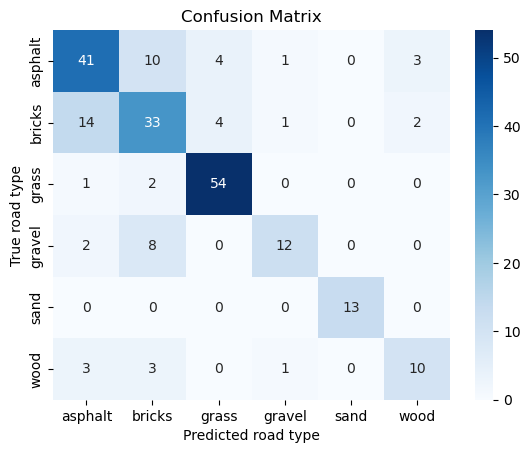

In [92]:
class_names = ['asphalt', 'bricks', 'grass', 'gravel', 'sand', 'wood']
conf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",xticklabels=class_names,
    yticklabels=class_names)

plt.xlabel("Predicted road type")
plt.ylabel("True road type")
plt.title("Confusion Matrix")
plt.show()

## DOCUMENTATIE

https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/